In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV
from function_future.margin_calculator import calculate_margin, get_instrument_info, get_first_trade_date, get_recent_activity

In [3]:
symbol_lst = ["RU", "BR", "NR", "L", "TA", "PF", "V", "EG", "MA", "PP", "EB", "UR", "SA", "SH", "PX", "PR"]

In [4]:
init_money_lst = []
for symbol in symbol_lst:
    margin = calculate_margin(symbol, 10)
    info = get_instrument_info(symbol)
    first_date = get_first_trade_date(symbol)
    activity = get_recent_activity(symbol)
    print(f"\n品种: {symbol} ({info.get('name', 'N/A')})")
    print(f"  首个交易日: {first_date}")
    print(f"  95分位数价格: {info['price_95th']:.2f}")
    print(f"  合约乘数: {info['contract_multiplier']}")
    print(f"  保证金率: {info['margin_rate']:.2%}")
    print(f"  10手保证金: {margin:,.2f} 元")
    print(f"  40%保证金所需本金: {margin / 0.4:,.0f} 元")
    # print(f"  交易所: {info['exchange']}")
    print(f"  分均持仓量: {activity['avg_open_interest']:,.0f}")
    print(f"  分均成交量: {activity['avg_volume']:,.0f}")
    print(f"  分均成交额: {activity['avg_turnover']:,.0f} 元")
    init_money_lst.append(int(margin / 0.4))


品种: RU (天然橡胶)
  首个交易日: 2021-02-08
  95分位数价格: 17035.00
  合约乘数: 10
  保证金率: 10.00%
  10手保证金: 170,350.00 元
  40%保证金所需本金: 425,875 元
  分均持仓量: 149,486
  分均成交量: 933
  分均成交额: 142,774,281 元

品种: BR (合成橡胶)
  首个交易日: 2023-07-28
  95分位数价格: 13670.00
  合约乘数: 10
  保证金率: 11.00%
  10手保证金: 150,370.00 元
  40%保证金所需本金: 375,925 元
  分均持仓量: 56,434
  分均成交量: 325
  分均成交额: 19,272,167 元

品种: NR (20号胶)
  首个交易日: 2021-06-17
  95分位数价格: 14470.00
  合约乘数: 10
  保证金率: 11.00%
  10手保证金: 159,170.00 元
  40%保证金所需本金: 397,925 元
  分均持仓量: 60,112
  分均成交量: 258
  分均成交额: 33,020,504 元

品种: L (塑料)
  首个交易日: 2021-02-02
  95分位数价格: 7702.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 26,957.00 元
  40%保证金所需本金: 67,392 元
  分均持仓量: 407,941
  分均成交量: 751
  分均成交额: 26,675,611 元

品种: TA (PTA)
  首个交易日: 2021-02-01
  95分位数价格: 5300.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 18,550.00 元
  40%保证金所需本金: 46,375 元
  分均持仓量: 1,131,266
  分均成交量: 3,136
  分均成交额: 76,415,381 元

品种: PF (短纤)
  首个交易日: 2021-02-01
  95分位数价格: 6734.00
  合约乘数: 5
  保证金率: 7.00%
  10手保证金: 23,569.00 元
  40%保证金所需本金:

In [5]:
initial_capital = dict(zip(symbol_lst, init_money_lst))
initial_capital

{'RU': 425875,
 'BR': 375925,
 'NR': 397925,
 'L': 67392,
 'TA': 46375,
 'PF': 58922,
 'V': 45080,
 'EG': 78627,
 'MA': 51020,
 'PP': 63822,
 'EB': 69652,
 'UR': 75040,
 'SA': 63944,
 'SH': 161160,
 'PX': 74600,
 'PR': 164220}

In [6]:
weights = dict(zip(symbol_lst, [5_000_000 // x for x in init_money_lst]))
weights

{'RU': 11,
 'BR': 13,
 'NR': 12,
 'L': 74,
 'TA': 107,
 'PF': 84,
 'V': 110,
 'EG': 63,
 'MA': 98,
 'PP': 78,
 'EB': 71,
 'UR': 66,
 'SA': 78,
 'SH': 31,
 'PX': 67,
 'PR': 30}

In [7]:
train_label = 5
rtn_mul = 1

bt_params = (0.9, 0.5, 10, 5*345)
train_end_date = '2025-01-01'

In [8]:
def run_res(symbol, bt_params):
    folder_name = f'{symbol}_pred{train_label}_{train_end_date}_v0'

    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = Path(config['MODEL_DIR']) / str(folder_name)

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = initial_capital[symbol]
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [9]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


 46%|████▋     | 42089/90524 [01:20<01:29, 542.57it/s]

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


 54%|█████▍    | 48947/90524 [01:33<01:16, 543.29it/s]

使用的交易价格 tick6t60avg


...

  5%|▌         | 4175/78931 [00:08<02:29, 501.12it/s]]50it/s]

使用的交易价格 tick6t60avg


 22%|██▏       | 17128/78931 [00:35<02:01, 506.78it/s]05it/s]

使用的交易价格 tick6t60avg


100%|██████████| 96318/96318 [03:25<00:00, 469.71it/s]


In [10]:
def plot_all(symbol_lst, merged_data_lst, weights=None):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.rename(columns={'equity':symbol}, inplace=True)
        df = df.groupby('date').last()
        # 如果有权重配置，应用权重
        if weights and symbol in weights:
            df[symbol] = df[symbol] * weights[symbol]

        df = df.iloc[:-30]

        pnl_ret.append(df)

    return pd.concat(pnl_ret,axis=1).ffill()

In [11]:
merged_df_all = plot_all(symbol_lst, merged_data_lst, weights=weights)
merged_df_all

,RU,BR,NR,L,TA,PF,V,EG,MA,PP,EB,UR,SA,SH,PX,PR
date,,,,,,,,,,,,,,,,
2025-01-02,4.868032e+06,4.927140e+06,4.761446e+06,5.132147e+06,4.985804e+06,5.260495e+06,4.764965e+06,4.957685e+06,5.108711e+06,5.000616e+06,4.772154e+06,4.723904e+06,4.973383e+06,4.610299e+06,4.851073e+06,4.736845e+06
2025-01-03,4.956175e+06,5.260822e+06,4.272713e+06,5.207102e+06,5.175610e+06,5.308873e+06,4.823686e+06,4.477608e+06,5.502266e+06,5.192220e+06,4.810228e+06,4.782803e+06,5.004610e+06,5.310649e+06,5.113432e+06,4.897304e+06
2025-01-06,5.027027e+06,5.253162e+06,4.457344e+06,5.156693e+06,5.434344e+06,5.532774e+06,4.701414e+06,4.633982e+06,5.508916e+06,5.284653e+06,4.912842e+06,4.746352e+06,4.888222e+06,5.009827e+06,5.459862e+06,5.039856e+06
2025-01-07,5.072447e+06,5.258401e+06,4.261146e+06,5.229023e+06,5.383978e+06,5.609772e+06,4.824375e+06,4.708696e+06,5.608972e+06,5.279886e+06,4.754003e+06,4.764789e+06,4.778662e+06,4.995635e+06,5.666491e+06,5.128878e+06
2025-01-08,5.010910e+06,5.476439e+06,4.262622e+06,5.259064e+06,5.346657e+06,5.710176e+06,4.833542e+06,4.681843e+06,5.629601e+06,5.344952e+06,4.714409e+06,4.832602e+06,4.773241e+06,5.167820e+06,5.690141e+06,5.097304e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-09,5.681831e+06,8.874387e+06,4.754446e+06,9.953767e+06,8.708973e+06,7.069073e+06,8.446833e+06,3.558918e+06,1.428278e+07,7.905904e+06,9.538025e+06,5.285877e+06,1.985753e+07,1.416429e+07,9.504199e+06,1.153333e+07
2026-01-12,5.681831e+06,8.874387e+06,4.754446e+06,9.953767e+06,8.708973e+06,7.143357e+06,8.446833e+06,3.558918e+06,1.428278e+07,7.905904e+06,9.538025e+06,5.285877e+06,1.985753e+07,1.416429e+07,9.504199e+06,1.153333e+07
2026-01-13,5.681831e+06,8.874387e+06,4.754446e+06,9.953767e+06,8.708973e+06,7.099024e+06,8.446833e+06,3.558918e+06,1.428278e+07,7.905904e+06,9.538025e+06,5.285877e+06,1.985753e+07,1.416429e+07,9.504199e+06,1.153333e+07


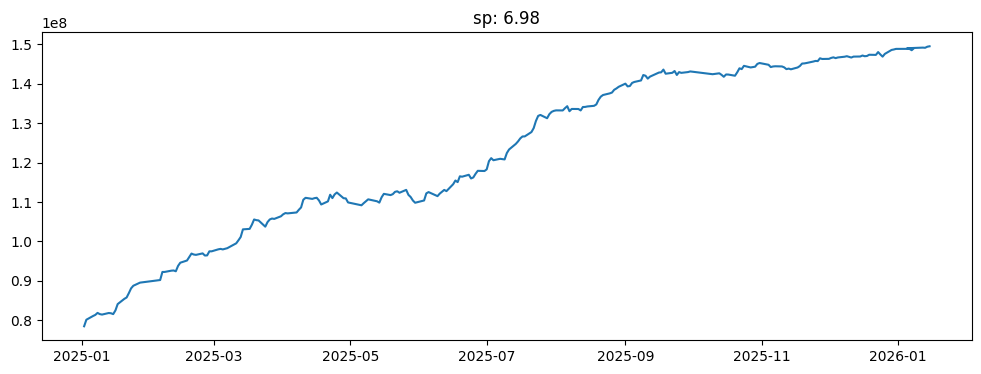

In [12]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()

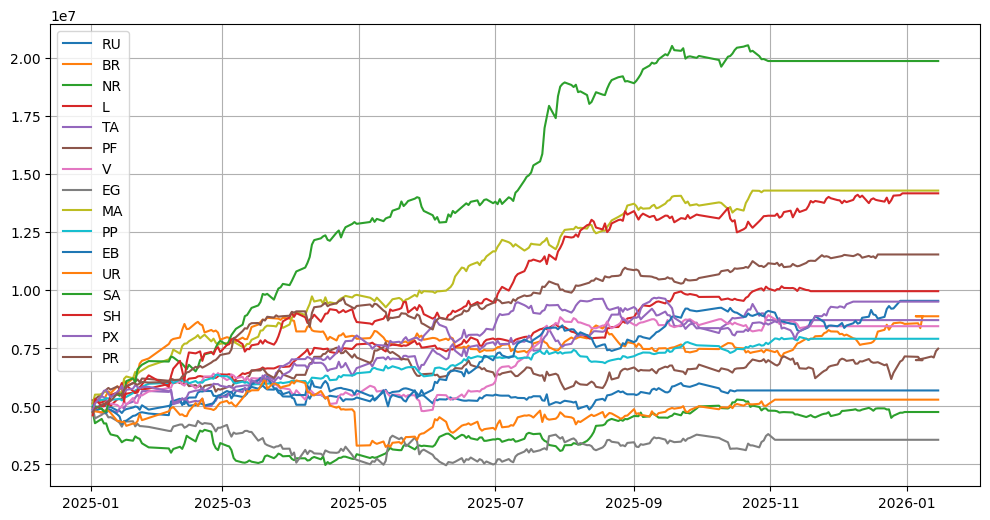

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(merged_df_all)
plt.legend(symbol_lst)
plt.grid()
plt.show()

In [15]:
res = pd.concat((bv.analyze_pos_distribution(merged_data_lst[i]) for i in range(len(symbol_lst))), axis=1)
res.columns = symbol_lst
res

,RU,BR,NR,L,TA,PF,V,EG,MA,PP,EB,UR,SA,SH,PX,PR
多头(+1) 数量,13813,18181,10404,17245,17234,21538,15748,15309,16292,15775,20385,11858,14896,19030,18127,20137
空头(-1) 数量,16618,20497,21326,16964,15034,16206,18599,17796,15306,15455,16991,10730,15047,17101,17839,17155
空仓(0) 数量,44369,55202,60995,48739,46007,58576,48601,45828,46332,51718,55223,29387,48677,56859,51503,53234
多头占比,18.47%,19.37%,11.22%,20.79%,22.02%,22.36%,18.99%,19.39%,20.91%,19.02%,22.01%,22.81%,18.95%,20.46%,20.72%,22.24%
空头占比,22.22%,21.83%,23.00%,20.45%,19.21%,16.83%,22.42%,22.55%,19.64%,18.63%,18.35%,20.64%,19.14%,18.39%,20.39%,18.95%
空仓占比,59.32%,58.80%,65.78%,58.76%,58.78%,60.81%,58.59%,58.06%,59.45%,62.35%,59.64%,56.54%,61.91%,61.15%,58.88%,58.81%
交易日数量,221,277,274,244,230,283,244,232,229,244,272,231,231,273,257,266
总收益(非年化%),15.21,58.13,5.59,71.21,109.54,126.73,90.62,6.97,209.31,53.20,67.29,29.33,319.44,201.92,115.05,105.19
总交易次数（开平算一次）,2567,3134,3067,3222,2529,2843,1834,3099,4270,1960,2953,1762,4847,4363,3903,3936
日均交易次数（开平算一次）,11.62,11.32,11.19,13.20,11.00,10.05,7.52,13.36,18.65,8.03,10.86,7.63,20.98,15.98,15.19,14.80
